# Introduction

The rapid expansion of digital payment systems, online banking, and e-commerce platforms has significantly increased the number of financial transactions conducted electronically. While these technologies provide convenience and efficiency, they have also created opportunities for fraudulent activities. Credit card fraud has become a major challenge for financial institutions, resulting in substantial financial losses and reduced customer trust.

Traditional fraud detection methods often rely on rule-based systems and manual monitoring. These approaches are limited because they cannot easily adapt to evolving fraud patterns. Machine learning techniques provide a more robust solution by learning patterns from historical transaction data and automatically identifying unusual or suspicious activities.

This project focuses on the development of a **cloud-based data science and machine learning pipeline for detecting fraudulent credit card transactions**. The system integrates several stages, including data ingestion, preprocessing, exploratory data analysis, machine learning model development, and performance evaluation.

The objective of this notebook is to build an **end-to-end machine learning workflow** that can analyze transaction data and accurately classify whether a transaction is legitimate or fraudulent.

---
# Sub-Objective 1:

## 1.1 Business Understanding

### 1. Problem Context

Credit card fraud occurs when unauthorized individuals gain access to a cardholder’s details and perform illegal transactions. With millions of transactions occurring daily across payment platforms, financial institutions require automated systems capable of detecting fraudulent activities quickly and accurately.

Manual monitoring of transactions is impractical due to the massive scale of data. Therefore, machine learning-based fraud detection systems are used to analyze transaction patterns and identify anomalies that may indicate fraudulent behavior.

Developing an effective fraud detection model is challenging because fraudulent transactions are extremely rare compared to normal transactions. This creates a **class imbalance problem**, which must be handled carefully during model development.

---

### 2. Business Objective

The primary business objective of this project is to **develop an automated fraud detection system** capable of identifying suspicious credit card transactions.

The system aims to:

- Detect fraudulent transactions with high accuracy
- Reduce financial losses caused by fraud
- Improve the efficiency of fraud monitoring systems
- Assist financial institutions in enhancing transaction security

---

### 3. Analytical Objective

From a data science perspective, the goal is to build a **binary classification model** that can categorize transactions into two classes:

- **0 → Normal Transaction**
- **1 → Fraudulent Transaction**

The model should be able to analyze transaction features and determine whether a transaction is legitimate or potentially fraudulent.

---

### 4. Key Challenges

One of the major challenges in credit card fraud detection is **class imbalance**. In real-world datasets, fraudulent transactions represent only a small percentage of total transactions.

For example:

- Normal transactions: approximately **99.83%**
- Fraudulent transactions: approximately **0.17%**

Because of this imbalance, many machine learning models may incorrectly favor the majority class (normal transactions), making it harder to detect fraud effectively.

Another challenge is minimizing **false positives**, where legitimate transactions are incorrectly flagged as fraudulent, which may negatively affect customer experience.

---

### 5. Success Criteria

The performance of the fraud detection system will be evaluated using several metrics:

- **Accuracy** – Overall correctness of the model predictions
- **Precision** – Proportion of predicted fraud cases that are actually fraudulent
- **Recall** – Ability of the model to correctly detect fraudulent transactions
- **F1 Score** – Harmonic mean of precision and recall

In fraud detection problems, **recall and F1 score are especially important**, because failing to detect a fraudulent transaction can lead to financial loss.

---

### 5. Expected Outcome

The final outcome of this project is a **cloud-based machine learning pipeline** that can automatically process transaction data, train fraud detection models, and evaluate their performance. The system will support financial institutions in identifying fraudulent transactions more efficiently and improving overall transaction security.

## 1.2 — Data Ingestion

**Purpose**

Data ingestion refers to the initial stage of a data pipeline where raw data is brought into the working environment for analysis and model development. In a machine learning workflow, this stage ensures that the dataset is correctly loaded, validated, and made accessible for downstream tasks such as preprocessing, exploratory analysis, and model training.

For this project, the **Credit Card Fraud Detection dataset** is used. The dataset contains anonymized financial transaction records that indicate whether a transaction is legitimate or fraudulent. Because the dataset includes a large number of observations and numerical attributes derived from transaction behavior, it is well suited for training classification models that identify suspicious activity.

The dataset file (`creditcard.csv`) is downloaded from the Kaggle repository and stored locally. It is then imported into the notebook using the **Pandas** library, which provides efficient data structures and tools for handling tabular data.

---

**Dataset Source**

- **Dataset:** Credit Card Fraud Detection  
- **Repository:** Kaggle Public Dataset  
- **File:** `creditcard.csv`

The dataset consists of **284,807 individual transaction records**, where each row corresponds to one credit card transaction.

Most variables are anonymized using **Principal Component Analysis (PCA)** to protect sensitive financial information. These transformed variables are labeled **V1 through V28**.

Additional attributes include:

- **Time** — Time difference between a transaction and the first recorded transaction  
- **Amount** — Monetary value of the transaction  
- **Class** — Target variable indicating whether the transaction is fraudulent  

Classification values:

- **0 → Legitimate transaction**
- **1 → Fraudulent transaction**

### 1. Loading the Dataset

The dataset is imported into a Pandas DataFrame to enable structured data operations such as filtering, aggregation, and statistical analysis.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Load dataset using relative path
df = pd.read_csv("../data/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2. Checking Dataset Shape

This step helps understand the size of the dataset.

In [2]:
print("Shape:", df.shape)

Shape: (284807, 31)


### 3. Display Column Names

In [3]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


### 4. Checking Basic Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 5. Checking Class Distribution

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### 6. Summary of Data Ingestion

At the completion of the data ingestion stage, several important outcomes have been achieved:

- The dataset has been successfully imported into the working environment.
- The structural characteristics of the dataset, including the number of rows and columns, have been verified.
- The available features and their data types have been inspected.
- The distribution of the target variable has been analyzed, revealing a significant class imbalance between normal and fraudulent transactions.
Following these Data Ingestion steps, the dataset is properly prepared for the next stage of the pipeline, which is **Data Pre-processing**.

## 1.3 — Data Pre-processing

**Purpose**

Data preprocessing is a fundamental stage in the data pipeline where the dataset is examined and prepared before applying machine learning algorithms. Raw data collected from real-world systems may contain inconsistencies, incorrect data types, missing values, or features with different scales. These issues can negatively affect the performance and reliability of machine learning models.

The objective of preprocessing is therefore to ensure that the dataset is **clean, structured, and suitable for analytical processing**. This stage improves data quality and helps models learn meaningful patterns from the data.

In practical machine learning workflows, preprocessing typically involves validating the dataset, identifying potential issues, and applying necessary transformations so that the data can be used effectively for training and evaluation.

For this project, the preprocessing process focuses on verifying the quality and structure of the credit card transaction dataset and preparing it for exploratory analysis and model development.

---

**Key Pre-processing Activities**

The following steps are performed during the preprocessing stage of the pipeline.


### 1. Display Summary Statistics

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 2. Check for Missing Values

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### 3. Display Data Types

In [8]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

### 4. Normalization of Numerical Data

Machine learning algorithms often perform better when features are scaled to a similar range. In this dataset:

PCA features (V1–V28) are already scaled

However, Time and Amount are not normalized

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original columns
df.drop(['Amount','Time'], axis=1, inplace=True)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


### 5. Verify Preprocessed Dataset

In [10]:
df.shape
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


### 6. Summary of Preprocessing

After completing the preprocessing stage, the following tasks have been accomplished:

- Key statistical properties of the dataset have been examined to understand feature distributions.
- The dataset has been checked for missing values to ensure data completeness.
- Data types of all variables have been validated to confirm they are suitable for analysis and model training.
- The numerical features **Amount** and **Time** have been normalized to maintain consistent feature scaling.

Following these preprocessing steps, the dataset is properly prepared for the next stage of the pipeline, which is **Exploratory Data Analysis (EDA)**.

## 1.4 — Exploratory Data Analysis (EDA)

**Purpose**

Exploratory Data Analysis (EDA) is an analytical stage where the dataset is examined to uncover patterns, relationships, and characteristics that may influence model performance. Before applying machine learning algorithms, it is important to explore how variables behave individually and how they interact with the target variable.

EDA helps analysts gain a deeper understanding of the dataset and guides decisions about feature selection, transformation, and modeling strategies. It also assists in detecting anomalies, unusual patterns, and potential issues that may affect predictive performance.

For the credit card fraud detection problem, EDA focuses on understanding how transaction features relate to fraudulent behavior and identifying signals that can help distinguish fraudulent transactions from legitimate ones.

---

**Key Exploratory Analysis Tasks**


### 1. Class Distribution Analysis
The first step is to examine how many transactions are fraudulent vs normal.

In [11]:
#Class Distribution Analysis
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

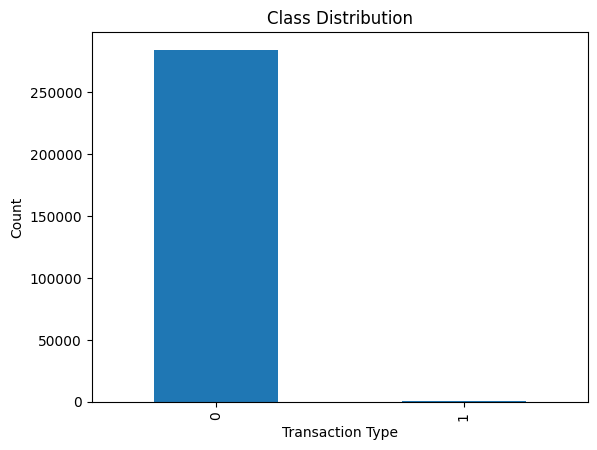

In [12]:
#To visualize this imbalance:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

### 2. Correlation Analysis

Correlation helps determine how strongly features are related to each other and to the target variable.

In [13]:
#Correlation Analysis
corr_matrix = df.corr()
corr_matrix.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
V1,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,7.388135e-17,...,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.101347,-0.227709,0.117396
V2,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,-3.991394e-16,...,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,0.091289,-0.531409,-0.010593
V3,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,1.156587e-15,...,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.192961,-0.210880,-0.419618
V4,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,2.232685e-16,...,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.133447,0.098732,-0.105260
V5,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,-5.202306e-16,...,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.094974,-0.386356,0.173072


### 3. Correlation Heatmap

A heatmap helps visually understand relationships between features.

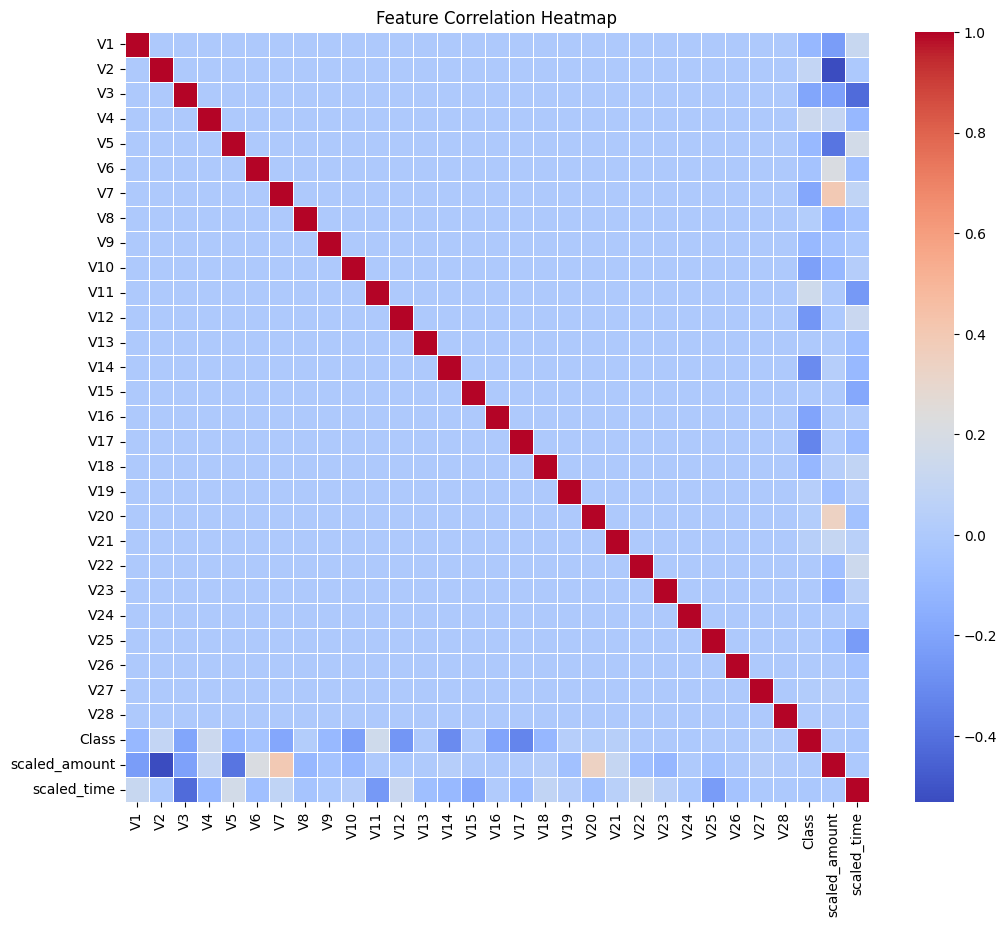

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### 4. Transaction Amount Distribution (Univariate Analysis)

Univariate analysis examines the distribution of a single variable.

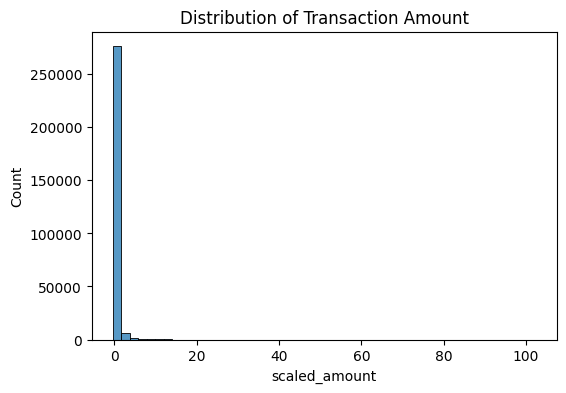

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['scaled_amount'], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()

### 5. Fraud vs Normal Transaction Amount (Bivariate Analysis)

Bivariate analysis studies the relationship between two variables.

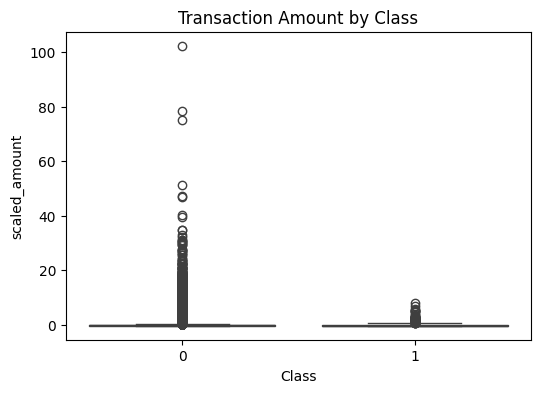

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='scaled_amount', data=df)
plt.title("Transaction Amount by Class")
plt.show()

### 6. Feature Importance

To understand which features contribute most to predicting fraud, a quick feature importance analysis can be performed using a tree-based model.

### 7. Spli feature and target variable 

In [17]:
X = df.drop('Class', axis=1)
y = df['Class']

Verfy data

In [18]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (284807, 30)
Target Shape: (284807,)


In [19]:
from sklearn.ensemble import ExtraTreesClassifier

# Train model
model = ExtraTreesClassifier(
    n_estimators=50,
    n_jobs=-1,
    random_state=42
)

model.fit(X, y)

# Feature importance
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns)

# Top 10 important features
feature_importance.nlargest(10)

V17    0.162681
V14    0.127132
V12    0.122552
V10    0.063181
V16    0.055003
V11    0.050519
V9     0.042041
V18    0.039895
V4     0.036852
V3     0.028713
dtype: float64

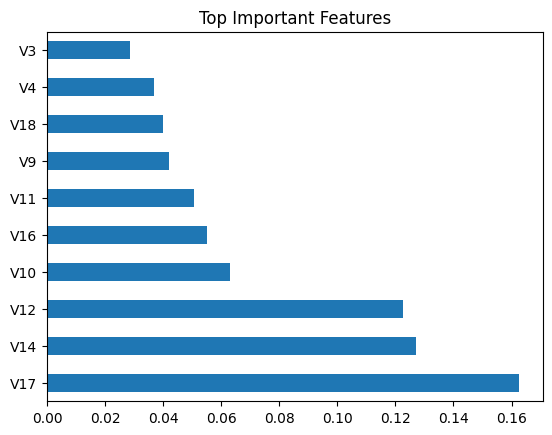

In [20]:
# Visualization:
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

### 8. Binning (Optional Feature Engineering)

Binning converts continuous variables into categories.

Example for transaction amounts:

In [21]:
from sklearn.preprocessing import RobustScaler

if 'Amount' in df.columns:
    scaler = RobustScaler()
    df['scaled_amount'] = scaler.fit_transform(df[['Amount']])

    df['amount_category'] = pd.qcut(
        df['scaled_amount'],
        q=4,
        labels=["Low","Medium","High","Very High"]
    )

    display(df[['Amount','scaled_amount','amount_category']].head())
else:
    print("Column 'Amount' not found in dataset")

Column 'Amount' not found in dataset


### 9. Summary of Exploratory Data Analysis (EDA)

The exploratory analysis of the dataset provides several important observations:

- The dataset is **highly imbalanced**, with fraudulent transactions representing only a very small fraction of the total records.
- Certain variables demonstrate **correlation with fraudulent activity**, indicating that some features may contribute more significantly to prediction.
- Analysis of the **transaction amount distribution** reveals patterns that may assist in identifying unusual or suspicious transactions.
- Preliminary examination of feature relationships suggests several **potentially important predictors** that could improve the performance of machine learning models.
- Insights obtained from EDA help guide **feature preparation, model selection, and evaluation strategies** in the subsequent stages of the machine learning pipeline.

Following these Exploratory Data Analysis (EDA) steps, the dataset is properly prepared for the next stage of the pipeline, which is **DataOps (Automating the Data Pipeline)**.

## 1.5 — DataOps (Automating the Data Pipeline)

**Purpose**

DataOps refers to the practices and technologies used to automate, monitor, and manage data workflows throughout the data lifecycle. In modern data-driven systems, pipelines must operate reliably and repeatedly without manual intervention. Automating these workflows ensures that data is consistently processed and available for analytics and machine learning applications.

In this project, DataOps is implemented by building an automated data pipeline that performs essential data processing tasks at scheduled intervals. The goal is to simulate how real-world production systems continuously process incoming data and maintain logs for monitoring and troubleshooting.

The automated pipeline includes the following activities:

- Loading the dataset (data ingestion)
- Performing preprocessing checks
- Running basic exploratory analysis
- Logging pipeline execution details
- Scheduling the workflow to run periodically
- Monitoring pipeline activity through log files

Automation improves **efficiency, reliability, traceability, and reproducibility**, which are important principles in modern data engineering and machine learning operations.

---

**Data Pipeline Workflow Design**

The automated pipeline follows a sequence of structured steps that are executed each time the workflow runs.

**1. Dataset Loading**

The pipeline begins by loading the dataset into memory so that it can be processed. This step ensures that the most recent version of the dataset is used during each execution.

**2. Preprocessing Checks**

Once the dataset is loaded, the pipeline performs basic validation and preprocessing checks. These include:

- Generating summary statistics
- Checking for missing values
- Verifying data integrity

These checks help confirm that the dataset remains valid and suitable for analysis.

**3. Basic Exploratory Analysis**

The pipeline performs a simple exploratory analysis by computing correlations between features. This provides a quick insight into relationships within the data and can help detect unexpected changes in the dataset.

**4. Logging Pipeline Activity**

Logging is implemented to record important pipeline events and outputs. Logs may include:

- Dataset loading status
- Results of preprocessing checks
- EDA outputs
- Execution timestamps

Maintaining logs is essential for monitoring system performance and diagnosing potential issues.

**5. Automated Scheduling**

The pipeline is configured to run automatically at fixed intervals. In this implementation, the workflow is scheduled to execute **every 3 minutes**. Scheduling ensures that data processing tasks occur consistently without requiring manual execution.

**6. Monitoring and Log Inspection**

Logs generated during pipeline execution can be reviewed to verify successful runs and identify potential problems. Monitoring helps maintain system reliability and provides visibility into the pipeline's operational status.

**Outcome of the DataOps Stage**

After implementing the automated pipeline:

- The data workflow becomes **automated and repeatable**
- Data processing tasks execute **periodically without manual intervention**
- Logs provide **traceability and monitoring capability**
- The system simulates a **production-style data engineering pipeline**

This automated setup ensures that the dataset is consistently prepared for downstream tasks, including **machine learning model training and evaluation**.

### 1. Import Required Libraries

In [22]:
import pandas as pd
import numpy as np
import logging
import schedule
import time
from sklearn.preprocessing import StandardScaler

### 2. Configure Logging

Logging is used to track pipeline activity and detect failures.

In [23]:
logging.basicConfig(
    filename="../logs/pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

This will record:
- Pipeline start time
- Preprocessing results
- Correlation results
- Pipeline completion status

### 3. Define the Data Pipeline Function

In [24]:
import pandas as pd
import logging
from sklearn.preprocessing import StandardScaler

logging.basicConfig(filename='pipeline.log', level=logging.INFO)

def data_pipeline():

    try:
        logging.info("Pipeline started")
        print("Pipeline started")

        # Data Ingestion
        df = pd.read_csv("../data/creditcard.csv")
        logging.info("Dataset loaded successfully")
        print("Dataset loaded successfully")

        # Summary statistics
        summary = df.describe()
        print(summary)
        logging.info("Summary statistics generated")

        # Missing value check
        missing_values = df.isnull().sum()
        print(missing_values)
        logging.info(f"Missing values:\n{missing_values}")

        # Data normalization
        scaler = StandardScaler()
        df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
        df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

        df.drop(['Amount','Time'], axis=1, inplace=True)
        logging.info("Data normalization completed")
        print("Normalization completed")

        # Correlation calculation
        correlation = df.corr()
        print(correlation)
        logging.info("Correlation matrix computed")

        logging.info("Pipeline executed successfully")
        print("Pipeline executed successfully")

    except Exception as e:
        logging.error(f"Pipeline failed due to error: {e}")
        print(f"Error: {e}")


# Run pipeline
data_pipeline()

Pipeline started
Dataset loaded successfully
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15 

### 4. Schedule the Pipeline

The schedule library allows tasks to run periodically.
Here, the pipeline will execute every 3 minutes.

In [25]:
import schedule
import time
schedule.every(3).minutes.do(data_pipeline)

Every 3 minutes do data_pipeline() (last run: [never], next run: 2026-03-17 15:52:23)

### 5. Run the Scheduler
The scheduler continuously checks if the pipeline needs to run and executes it at the defined interval.

In [26]:
for _ in range(10):   # runs 10 times
    schedule.run_pending()
    time.sleep(1)

These logs can be visualized in cloud dashboards using monitoring tools such as:

 - AWS CloudWatch
 - Azure Monitor
 - Grafana
 - ELK Stack (Elasticsearch, Logstash, Kibana)

### 6. Summary of DataOps Implementation

The implemented DataOps pipeline provides the following capabilities:

- **Automated data ingestion** to load the dataset into the processing environment.
- **Automated data preprocessing** to validate and prepare the dataset for analysis.
- **Automated execution of basic EDA checks** to monitor dataset characteristics.
- **Logging and monitoring** to track pipeline activities and detect errors.
- **Scheduled pipeline execution every 3 minutes** to simulate a continuous data processing workflow.

These mechanisms ensure that the data preparation process is **repeatable, observable, and suitable for production-style environments**.

---

### 7. Completion of Sub-Objective 1

At this stage, the **Data Pipeline** has been successfully designed and automated.

The pipeline implementation includes the following stages:

- **Business understanding**
- **Data ingestion**
- **Data preprocessing**
- **Exploratory data analysis**
- **DataOps automation**

With these components in place, the data is consistently prepared and ready for the next phase of the project, which involves **designing and implementing the machine learning pipeline**.

# Sub-Objective 2 — Machine Learning Pipeline

**Purpose**

Model preparation is the stage where appropriate machine learning algorithms are selected to solve the defined problem. In this project, the task is to detect fraudulent credit card transactions, which falls under **binary classification**.

A binary classification model predicts whether a transaction belongs to one of two possible classes:

- **0 → Normal Transaction**
- **1 → Fraudulent Transaction**

Selecting suitable algorithms is an important step because the model must accurately identify rare fraudulent transactions while minimizing incorrect predictions.

When choosing machine learning models for fraud detection, several factors are considered:

- Ability to handle **large datasets**
- Capability to manage **highly imbalanced data**
- Ability to capture **complex relationships between features**
- Strong **predictive performance and robustness**

To address these requirements, two ensemble learning algorithms are selected for this project.


### 2.1 Model Preparation (Code)
#### 1. Import Required Libraries

In [27]:
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest Model:")
print(rf_model)

Random Forest Model:
RandomForestClassifier(random_state=42)


In [29]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("\nXGBoost Model:")
print(xgb_model)


XGBoost Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


#### 4. Summary

In this step:

- Two machine learning algorithms were selected and prepared for model development:
  - **Random Forest Classifier**
  - **XGBoost Classifier**
- The models were initialized with their default configurations and are now ready for the training phase.

#### 1. Split Dataset into Training and Testing Sets

The train_test_split function from scikit-learn is used for splitting the dataset.

In [30]:
# Remove categorical column used only for EDA
df = df.drop(columns=['amount_category'], errors='ignore')

In [31]:
X = df.drop('Class', axis=1)
y = df['Class']

In [32]:
# Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### 2. Verify Dataset Split

In [33]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (199364, 30)
Testing Features Shape: (85443, 30)
Training Target Shape: (199364,)
Testing Target Shape: (85443,)


## 2.2 — Model Training

**Purpose**

Model training is the stage in the machine learning pipeline where algorithms learn patterns from historical data. During this process, the model analyzes relationships between the input features and the target variable in order to build a predictive model capable of classifying new, unseen transactions.

Training allows the algorithm to identify patterns that distinguish **fraudulent transactions from normal transactions**, enabling the system to make accurate predictions during real-world usage.

To properly assess the model's effectiveness, the dataset is divided into two subsets:

- **Training Data (70%)** → Used to train the machine learning model and allow it to learn patterns from the data.
- **Testing Data (30%)** → Used to evaluate how well the trained model performs on unseen data.

This separation is important because it helps determine whether the model has learned generalizable patterns or if it has simply memorized the training data. Evaluating the model on a separate testing dataset provides a more reliable measure of its predictive performance.

#### 1. Algorithm 1: Random Forest

**Overview**

Random Forest is an **ensemble learning algorithm** that builds multiple decision trees during training and combines their predictions to produce a final result.

Instead of relying on a single decision tree, Random Forest improves predictive performance by using a collection of trees. Each tree is trained on a **random subset of the dataset and features**, which helps create diverse models.

The prediction process works as follows:

- Multiple decision trees are created using different random samples of the dataset.
- Each decision tree independently predicts the class of a transaction.
- The final prediction is determined through **majority voting**, where the class predicted by most trees becomes the final output.

This ensemble approach helps reduce variance and improve the robustness of the model.

---

**Why Random Forest is Suitable**

Random Forest is well suited for fraud detection tasks due to several advantages:

- It can handle **high-dimensional datasets** with many features.
- The ensemble structure helps **reduce overfitting** compared to single decision trees.
- The model can estimate **feature importance**, which helps identify variables that influence predictions.
- It performs well in detecting **complex and non-linear relationships** within the data.

In [34]:
# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced', 
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

After training, the model has learned patterns that differentiate fraudulent and normal transactions.

#### 2. Algorithm 2: XGBoost (Extreme Gradient Boosting)

**Overview**

XGBoost (Extreme Gradient Boosting) is a powerful machine learning algorithm based on the **gradient boosting framework**. It builds an ensemble of decision trees in a **sequential manner**, where each new tree is trained to correct the errors made by the previous trees.

Unlike Random Forest, which builds multiple trees independently and combines their outputs through averaging, XGBoost follows a **boosting approach**. In this approach:

- Models are trained **iteratively**
- Each subsequent model focuses on **minimizing the residual errors**
- The overall model improves step-by-step by learning from past mistakes

This sequential learning mechanism allows XGBoost to capture **complex, non-linear relationships** in the data, making it highly effective for predictive tasks.

---

**Why XGBoost is Suitable for Fraud Detection**

XGBoost is widely used in real-world machine learning systems, especially in **fraud detection**, due to the following advantages:

- **High Predictive Accuracy**  
  XGBoost often outperforms traditional algorithms such as Logistic Regression and Random Forest by effectively reducing prediction errors.

- **Handles Imbalanced Data Well**  
  Fraud detection datasets are highly imbalanced. XGBoost provides parameters such as `scale_pos_weight` to address this issue.

- **Regularization Support**  
  Built-in L1 (Lasso) and L2 (Ridge) regularization helps prevent overfitting and improves generalization.

- **Optimized Performance**  
  XGBoost is designed for speed and efficiency using parallel processing and optimized memory usage.

- **Scalability**  
  It can efficiently handle large-scale datasets with high-dimensional features.

- **Feature Importance Analysis**  
  Provides insights into which features contribute most to fraud detection.

### 3. Train XGBoost Model

Similarly, the XGBoost model is trained using the same training dataset.

In [35]:
# Count class distribution
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()

print("Negative:", num_neg)
print("Positive:", num_pos)

Negative: 199020
Positive: 344


In [36]:
scale_pos_weight = 0.3 * (num_neg / num_pos)
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 173.56395348837208


In [37]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [38]:
# Get probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

In [39]:
# Adjust threshold (try 0.4–0.45)
threshold = 0.55

xgb_predictions = (xgb_probs > threshold).astype(int)

### 4. Confirm Model Training

In [40]:
print("Random Forest training completed.")
print("XGBoost training completed.")

Random Forest training completed.
XGBoost training completed.


### 5. Summary of Model Training

At the completion of the model training stage, the following tasks have been accomplished:

- The dataset has been divided into **training and testing subsets** to ensure reliable model evaluation.
- Two machine learning models have been successfully trained:
  - **Random Forest Classifier**
  - **XGBoost Classifier**
- Each model has learned patterns and relationships from historical transaction data.

The trained models are now prepared for the **model evaluation phase**, where their predictive performance will be assessed using appropriate evaluation metrics.

## 2.3 — Model Evaluation

**Purpose**

Model evaluation assesses how well the trained machine learning models perform on data that was not used during training. After the models learn patterns from the training dataset, their predictive capability is tested using the **testing dataset (30%)**.

Evaluating models on unseen data helps determine whether the model has learned generalizable patterns or if it has overfitted the training data.

In fraud detection problems, the dataset is typically **highly imbalanced**, meaning that fraudulent transactions represent only a small fraction of the total data. Because of this imbalance, relying solely on accuracy can produce misleading results. A model might achieve high accuracy simply by predicting most transactions as normal.

Therefore, additional evaluation metrics such as **precision, recall, and F1 score** are used to provide a more comprehensive assessment of model performance.

---

**Evaluation Metrics**

| Metric | Meaning |
|------|------|
| **Accuracy** | Percentage of transactions correctly classified by the model |
| **Precision** | Out of all transactions predicted as fraud, the proportion that are actually fraudulent |
| **Recall** | Out of all actual fraudulent transactions, the proportion correctly detected by the model |
| **F1 Score** | Harmonic mean of precision and recall, balancing both false positives and false negatives |

These metrics help measure the model’s ability to **accurately detect fraudulent transactions while minimizing incorrect fraud alerts**.

### 1. Import Evaluation Libraries

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

### 2. Make Predictions Using Random Forest

In [42]:
# Random Forest predictions

rf_predictions = rf_model.predict(X_test)

### 3. Evaluate Random Forest Model

In [43]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Model Performance")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest Model Performance
Accuracy: 0.9993679997191109
Precision: 0.8615384615384616
Recall: 0.7567567567567568
F1 Score: 0.8057553956834532


### 4. Make Predictions Using XGBoost

In [44]:
# Get probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Lower threshold (tune between 0.2–0.4)
threshold = 0.3

xgb_predictions = (xgb_probs > threshold).astype(int)

### 5. Evaluate XGBoost Model

In [45]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)

print("XGBoost Model Performance")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)

XGBoost Model Performance
Accuracy: 0.9985136289690203
Precision: 0.5462555066079295
Recall: 0.8378378378378378
F1 Score: 0.6613333333333333


### 6. Display Detailed Classification Report

In [46]:
print("Random Forest Classification Report")
print(classification_report(y_test, rf_predictions))

print("XGBoost Classification Report")
print(classification_report(y_test, xgb_predictions))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.76      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443

XGBoost Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.55      0.84      0.66       148

    accuracy                           1.00     85443
   macro avg       0.77      0.92      0.83     85443
weighted avg       1.00      1.00      1.00     85443



### 7. Summary of Model Evaluation

At the completion of the model evaluation stage, the following tasks have been performed:

- Predictions were generated for both trained models.
- Four key evaluation metrics were calculated to assess model performance:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1 Score**
- A detailed **classification report** was produced to summarize the performance of each model across the evaluation metrics.
- The predictive performance of the **Random Forest** and **XGBoost** models was analyzed and compared.

These evaluation metrics provide insights into how effectively each model detects fraudulent transactions and help identify the model that performs better for fraud detection tasks.

## 2.4 — MLOps (Model Monitoring and Logging)

**Purpose**

MLOps (Machine Learning Operations) focuses on the deployment, monitoring, and maintenance of machine learning models in production environments. Once models are trained and deployed, it is important to continuously monitor their performance to ensure they remain reliable and effective over time.

In real-world systems, machine learning models may experience issues such as **data drift**, **performance degradation**, or unexpected failures. Continuous monitoring helps detect these issues early so that corrective actions, such as retraining or updating the model, can be performed.

In this project, the MLOps stage includes the following activities:

- Monitoring the performance of trained models  
- Logging important evaluation metrics  
- Tracking model prediction activity  
- Automating the monitoring workflow  

To evaluate model performance consistently, the following metrics are recorded and monitored:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

These metrics provide insights into how effectively the model identifies fraudulent transactions while minimizing incorrect predictions. Logging these values over time enables continuous monitoring and supports maintaining reliable model performance in a production-like environment.

### 1. Import Logging Library

In [47]:
import logging

### 2. Configure Model Monitoring Logs

A log file will store all model performance metrics.

In [48]:
logging.basicConfig(
    filename="model_monitoring.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

### 3. Define Model Monitoring Function

This function records evaluation metrics of the trained models.

In [49]:
def monitor_models():

    try:
        logging.info("Model monitoring started")

        rf_accuracy = accuracy_score(y_test, rf_predictions)
        rf_precision = precision_score(y_test, rf_predictions)
        rf_recall = recall_score(y_test, rf_predictions)
        rf_f1 = f1_score(y_test, rf_predictions)

        print("Random Forest Metrics")
        print("Accuracy:", rf_accuracy)
        print("Precision:", rf_precision)
        print("Recall:", rf_recall)
        print("F1 Score:", rf_f1)

        logging.info(f"RF Accuracy: {rf_accuracy}")
        logging.info(f"RF Precision: {rf_precision}")
        logging.info(f"RF Recall: {rf_recall}")
        logging.info(f"RF F1: {rf_f1}")

        xgb_accuracy = accuracy_score(y_test, xgb_predictions)
        xgb_precision = precision_score(y_test, xgb_predictions)
        xgb_recall = recall_score(y_test, xgb_predictions)
        xgb_f1 = f1_score(y_test, xgb_predictions)

        print("\nXGBoost Metrics")
        print("Accuracy:", xgb_accuracy)
        print("Precision:", xgb_precision)
        print("Recall:", xgb_recall)
        print("F1 Score:", xgb_f1)

        logging.info(f"XGB Accuracy: {xgb_accuracy}")
        logging.info(f"XGB Precision: {xgb_precision}")
        logging.info(f"XGB Recall: {xgb_recall}")
        logging.info(f"XGB F1: {xgb_f1}")

        logging.info("Model monitoring completed")

    except Exception as e:
        logging.error(f"Monitoring failed: {e}")

### 4. Run Model Monitoring

In [50]:
monitor_models()

Random Forest Metrics
Accuracy: 0.9993679997191109
Precision: 0.8615384615384616
Recall: 0.7567567567567568
F1 Score: 0.8057553956834532

XGBoost Metrics
Accuracy: 0.9985136289690203
Precision: 0.5462555066079295
Recall: 0.8378378378378378
F1 Score: 0.6613333333333333


### 5. Summary of MLOps Monitoring

To maintain model reliability, an **MLOps monitoring system** was implemented.

The monitoring system:

- Tracks model performance
- Logs evaluation metrics
- Records monitoring events
- Detects potential performance degradation

# Sub-Objective 3 — API Access

**Purpose**

After building the data pipeline and machine learning pipeline, the final stage of the project is to provide **API access** so that external systems can interact with the trained machine learning model.

In real-world applications, machine learning models are typically deployed as **REST APIs**. These APIs allow external systems such as **web applications, dashboards, financial platforms, or payment gateways** to send transaction data to the model and receive predictions in real time.

By exposing the model through an API, the fraud detection system can be integrated into existing applications and used for **automated transaction verification**.

In this project, the API will perform the following functions:

- Accept transaction data as input
- Process the data using the trained machine learning model
- Return a prediction indicating whether the transaction is fraudulent or legitimate

The prediction result enables external systems to take appropriate actions, such as flagging suspicious transactions or blocking potentially fraudulent payments.


### 3.1 — Save the Trained Model

Before creating the API, the trained model must be saved so it can be loaded by the API service.

In [51]:
import joblib

# Save the trained XGBoost model
joblib.dump(model, "../models/fraud_detection_model.pkl")

print("Model saved successfully")

Model saved successfully
